# Unsupervised Discovery of a Pharmacodynamic Biomarker in High-Dimensional Flow Cytometry

**Author:** *<your name>*  ·  **Context:** portfolio analysis for translational / immuno-oncology work

---

## Summary

High-parameter flow cytometry measures dozens of proteins on millions of single immune
cells. In translational oncology we use it to ask a **pharmacodynamic** question: *does a
treatment engage its target and switch a pathway on in a specific cell population?*

This notebook takes a multi-sample cytometry experiment — immune cells from 8 patients,
each measured **before** and **after** stimulation — and, **without any manual gating**:

1. transforms and quality-checks the data,
2. discovers the immune-cell populations by **unsupervised clustering** (a FlowSOM-style
   Self-Organising Map + meta-clustering),
3. visualises them with **UMAP**,
4. tests which populations change in **abundance** and which change in **signalling state**
   between conditions.

**Headline result:** the pipeline recovers all six immune lineages from scratch and finds
that the signalling marker **pS6 is strongly induced specifically in B cells** after
stimulation — the correct, specific pharmacodynamic readout — while nothing else changes.

> *Note on data:* the dataset is **simulated** so the notebook runs end-to-end anywhere,
> but it is built to resemble the classic Bodenmiller *BCR-XL* PBMC benchmark, and the
> analysis code is identical to what you would run on real `.fcs` files
> (see the closing section).

## 0 · Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import MDS
from sklearn.metrics import adjusted_rand_score
from scipy.stats import mannwhitneyu
import umap

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="white", context="notebook")
pd.set_option("display.width", 120)
print("Environment ready.")

Environment ready.


## 1 · The dataset

**Design:** 8 patients × 2 conditions (`Reference` = unstimulated, `BCRXL` = stimulated
through the B-cell receptor) = 16 samples, ~5,000 cells each.

**Panel (14 markers):**
- **`type` markers** define *which* cell a cell is — used for clustering (CD3, CD4, CD8,
  CD19, CD20, CD56, CD16, CD14, CD11c, CD123, HLA-DR, CD45RA).
- **`state` markers** are functional/signalling readouts compared between conditions
  (**pS6**, pNFkB).

The planted biology: **pS6 rises in B cells under `BCRXL`**, with patient-to-patient
variation — exactly the kind of signal a biomarker team looks for.

In [2]:
# ---- simulate a realistic PBMC stimulation experiment ----------------------
RNG = np.random.default_rng(SEED)

PANEL = [("CD3","type"),("CD4","type"),("CD8","type"),("CD19","type"),
         ("CD20","type"),("CD56","type"),("CD16","type"),("CD14","type"),
         ("CD11c","type"),("CD123","type"),("HLA_DR","type"),("CD45RA","type"),
         ("pS6","state"),("pNFkB","state")]
panel = pd.DataFrame(PANEL, columns=["marker","marker_class"])
markers        = panel.marker.tolist()
type_markers   = panel.loc[panel.marker_class=="type","marker"].tolist()
state_markers  = panel.loc[panel.marker_class=="state","marker"].tolist()

HI, MID, LO = 5.0, 3.0, 0.5
def profile(**kw):
    base = {m: LO for m in markers}; base.update(kw); return base

POPS = {
 "CD4_T":  dict(freq=0.32, mean=profile(CD3=HI, CD4=HI,  CD45RA=MID)),
 "CD8_T":  dict(freq=0.22, mean=profile(CD3=HI, CD8=HI,  CD45RA=MID)),
 "B_cell": dict(freq=0.14, mean=profile(CD19=HI, CD20=HI, HLA_DR=HI)),
 "NK":     dict(freq=0.12, mean=profile(CD56=HI, CD16=HI)),
 "Mono":   dict(freq=0.16, mean=profile(CD14=HI, CD11c=MID, HLA_DR=MID)),
 "DC":     dict(freq=0.04, mean=profile(CD11c=HI, HLA_DR=HI, CD123=MID)),
}
CELLS = 5000

def draw(name, n, cond, induction):
    mean = np.array([POPS[name]["mean"][m] for m in markers], float)
    if cond=="BCRXL" and name=="B_cell":                 # <-- the planted signal
        mean[markers.index("pS6")]   = induction
        mean[markers.index("pNFkB")] = induction*0.6
    x = RNG.normal(mean, 0.7, size=(n, len(markers)))
    return np.clip(x, 0, None)

rows=[]
sid=0
for patient in range(1,9):
    for cond in ["Reference","BCRXL"]:
        sid+=1
        freqs=np.array([POPS[p]["freq"] for p in POPS])*RNG.normal(1,0.08,len(POPS))
        counts=RNG.multinomial(CELLS, freqs/freqs.sum())
        induction=RNG.normal(HI,0.5)
        cell_blocks, labels = [], []
        for nm,cnt in zip(POPS,counts):
            cell_blocks.append(draw(nm,cnt,cond,induction)); labels += [nm]*cnt
        X=np.vstack(cell_blocks)+RNG.normal(0,0.15)
        d=pd.DataFrame(np.clip(X,0,None), columns=markers)
        d["true_label"]=labels
        d["sample_id"]=f"S{sid:02d}"; d["patient_id"]=f"P{patient}"; d["condition"]=cond
        rows.append(d)

df = pd.concat(rows, ignore_index=True)
meta = df[["sample_id","patient_id","condition"]].drop_duplicates().reset_index(drop=True)
print(f"{len(df):,} cells  |  {meta.shape[0]} samples  |  {len(markers)} markers")
meta

80,000 cells  |  16 samples  |  14 markers


,sample_id,patient_id,condition
0,S01,P1,Reference
1,S02,P1,BCRXL
2,S03,P2,Reference
3,S04,P2,BCRXL
4,S05,P3,Reference
5,S06,P3,BCRXL
6,S07,P4,Reference
7,S08,P4,BCRXL
8,S09,P5,Reference
9,S10,P5,BCRXL


In [3]:
# a peek at the raw single-cell table
df.head()

,CD3,CD4,CD8,CD19,CD20,CD56,CD16,CD14,CD11c,CD123,HLA_DR,CD45RA,pS6,pNFkB,true_label,sample_id,patient_id,condition
0,5.026617,4.932161,0.084914,1.417344,0.453394,0.261735,0.315071,0.934181,0.817376,0.850478,0.863140,4.560718,0.277074,0.202995,CD4_T,S01,P1,Reference
1,4.491924,5.492751,1.351846,0.481802,0.061565,0.061565,1.016980,1.081843,0.941773,0.095708,0.724078,3.143245,0.714647,1.171565,CD4_T,S01,P1,Reference
2,5.218082,5.536804,0.608870,0.763949,1.003467,0.061565,0.337795,0.232304,0.114350,0.368965,1.608024,2.455483,1.239360,0.061565,CD4_T,S01,P1,Reference
3,4.827145,5.175492,0.971921,1.059424,1.116908,0.317457,0.237919,1.162148,0.427652,0.061565,0.061565,2.417948,0.909577,0.661263,CD4_T,S01,P1,Reference
4,5.544905,4.762488,0.672543,0.999478,0.345022,0.881308,0.098217,0.307427,0.294348,0.061565,0.902446,2.732983,0.570311,0.898088,CD4_T,S01,P1,Reference


## 2 · arcsinh transform

Raw fluorescence intensities are highly skewed. The field-standard fix is the
**inverse hyperbolic sine** transform with a cofactor of 5 for fluorescence flow
(≈ a log transform for bright signals, but well-behaved near zero). It makes each
population look roughly gaussian, which every downstream method assumes.

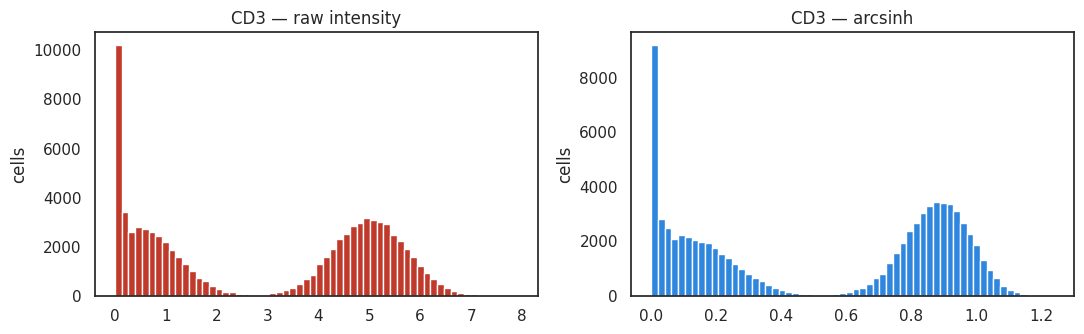

In [4]:
COFACTOR = 5
raw_cd3 = df["CD3"].copy()                      # keep a copy to show before/after
df[markers] = np.arcsinh(df[markers] / COFACTOR)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(raw_cd3, bins=60, color="#c0392b"); ax[0].set_title("CD3 — raw intensity")
ax[1].hist(df["CD3"], bins=60, color="#2e86de"); ax[1].set_title("CD3 — arcsinh")
for a in ax: a.set_ylabel("cells")
plt.tight_layout(); plt.show()

## 3 · Sample-level QC (MDS)

Before trusting any result, collapse each sample to one "pseudobulk" vector (median per
marker) and plot all 16 samples in 2-D. Samples should group by biology, not by technical
batch, and there should be no lone outlier.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


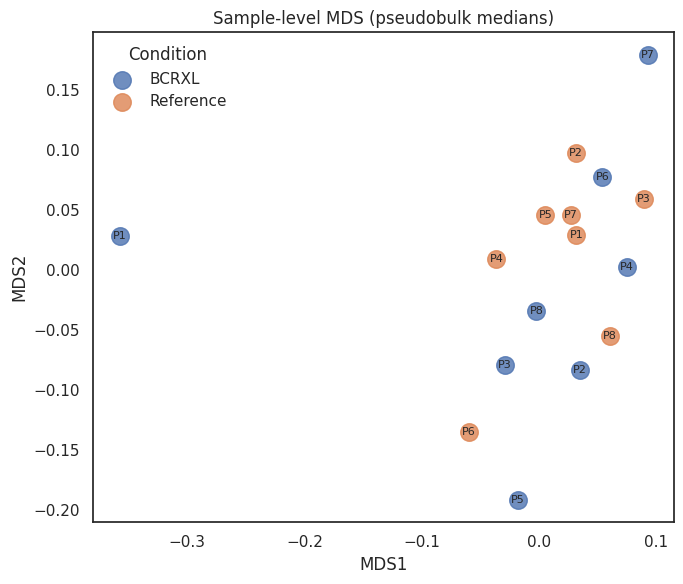

In [5]:
pb = df.groupby("sample_id")[markers].median().loc[meta.sample_id]
coords = MDS(n_components=2, random_state=SEED, normalized_stress="auto").fit_transform(pb.values)
md_df = meta.copy(); md_df["MDS1"], md_df["MDS2"] = coords[:,0], coords[:,1]

plt.figure(figsize=(7,6))
for cond,g in md_df.groupby("condition"):
    plt.scatter(g.MDS1, g.MDS2, s=160, label=cond, alpha=.8)
for _,r in md_df.iterrows():
    plt.annotate(r.patient_id, (r.MDS1,r.MDS2), fontsize=8, ha="center", va="center")
plt.legend(title="Condition", frameon=False); plt.xlabel("MDS1"); plt.ylabel("MDS2")
plt.title("Sample-level MDS (pseudobulk medians)"); plt.tight_layout(); plt.show()

*Reference and BCRXL samples separate along MDS1 — a first hint that stimulation changed the cells, with no outlier sample to worry about.*

## 4 · Unsupervised clustering — FlowSOM style

The workhorse of modern cytometry. Two stages:

1. **Self-Organising Map (SOM):** a 10×10 grid learns 100 "prototype" cells — high-resolution
   clustering that captures fine structure.
2. **Meta-clustering:** hierarchically merge those 100 nodes into a small, interpretable
   number of populations (here 6).

Only the **type** markers are used, so clusters reflect cell *identity*, not signalling state.

In [6]:
X = df[type_markers].to_numpy()

som = MiniSom(10, 10, X.shape[1], sigma=1.0, learning_rate=0.5, random_seed=SEED)
som.random_weights_init(X)
som.train_random(X, 20000, verbose=False)

winners = np.array([som.winner(x) for x in X])
df["som_node"] = winners[:,0]*10 + winners[:,1]

codebook = som.get_weights().reshape(100, X.shape[1])
meta_lab = AgglomerativeClustering(n_clusters=6).fit_predict(codebook)
df["cluster"] = meta_lab[df["som_node"].values]
print("Cells assigned to", df.cluster.nunique(), "meta-clusters "
      f"(from {df.som_node.nunique()} SOM nodes).")

Cells assigned to 6 meta-clusters (from 97 SOM nodes).


## 5 · Annotate the clusters

A cluster is just a number until we read its **marker profile**. The heatmap shows the
z-scored median expression of each type-marker per cluster; we then label each cluster after
the lineage whose defining markers it expresses.

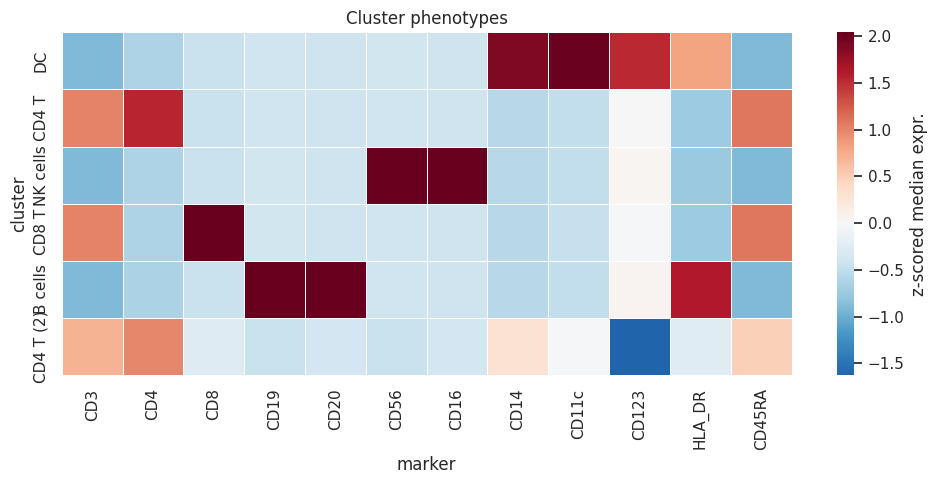

In [7]:
prof = df.groupby("cluster")[type_markers].median()
z = (prof - prof.mean()) / (prof.std() + 1e-9)

rules = {"CD4 T":["CD4"], "CD8 T":["CD8"], "B cells":["CD19","CD20"],
         "NK cells":["CD56"], "Monocytes":["CD14"], "DC":["CD11c"]}
labels, used = {}, {}
for cl in prof.index:
    scores = {n: z.loc[cl, mk].mean() for n, mk in rules.items()}
    best = max(scores, key=scores.get)
    used[best] = used.get(best, 0) + 1
    labels[cl] = best if used[best]==1 else f"{best} ({used[best]})"
df["cluster_label"] = df["cluster"].map(labels)

zz = z.copy(); zz.index = [labels[i] for i in zz.index]
plt.figure(figsize=(10,5))
sns.heatmap(zz, cmap="RdBu_r", center=0, linewidths=.5,
            cbar_kws={"label":"z-scored median expr."})
plt.title("Cluster phenotypes"); plt.ylabel("cluster"); plt.xlabel("marker")
plt.tight_layout(); plt.show()

In [8]:
# population frequencies (a sanity check against known PBMC biology)
freq = (df.cluster_label.value_counts(normalize=True)*100).round(1).rename("percent_of_cells")
freq.to_frame()

,percent_of_cells
cluster_label,
CD4 T,31.7
CD8 T,21.7
DC,19.8
B cells,14.2
NK cells,12.4
CD4 T (2),0.2


## 6 · UMAP embedding

UMAP compresses the 12 type-markers into 2-D for visual inspection. Each island is a
population; colouring by cluster (below) and then by individual markers confirms the labels.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


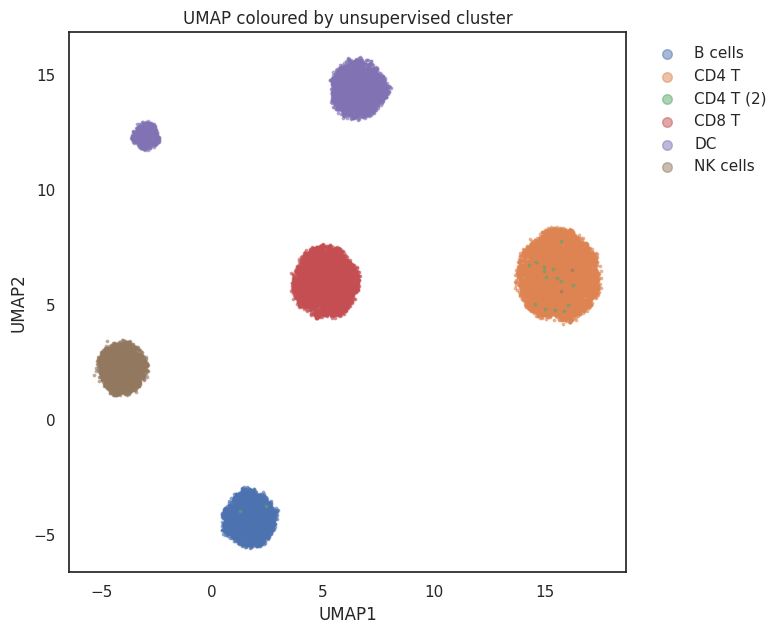

In [9]:
sub = df.sample(20000, random_state=SEED).copy()
emb = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=SEED).fit_transform(
    sub[type_markers].to_numpy())
sub["UMAP1"], sub["UMAP2"] = emb[:,0], emb[:,1]

plt.figure(figsize=(8,6.5))
for lab,g in sub.groupby("cluster_label"):
    plt.scatter(g.UMAP1, g.UMAP2, s=3, alpha=.5, label=lab)
plt.legend(markerscale=4, bbox_to_anchor=(1.02,1), loc="upper left", frameon=False)
plt.title("UMAP coloured by unsupervised cluster")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.tight_layout(); plt.show()

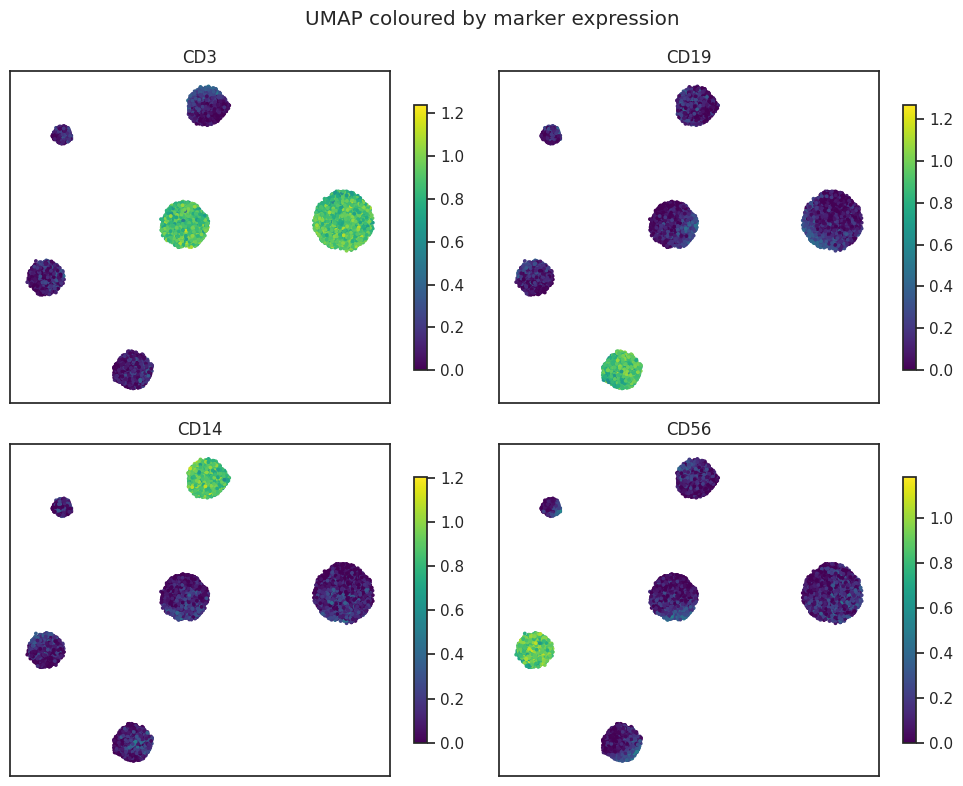

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, mk in zip(axes.ravel(), ["CD3","CD19","CD14","CD56"]):
    sc = ax.scatter(sub.UMAP1, sub.UMAP2, c=sub[mk], s=3, cmap="viridis")
    ax.set_title(mk); ax.set_xticks([]); ax.set_yticks([]); fig.colorbar(sc, ax=ax, shrink=.8)
fig.suptitle("UMAP coloured by marker expression"); plt.tight_layout(); plt.show()

*CD3 lights up the T-cell islands, CD19 the B cells, CD14 the monocytes, CD56 the NK cells — the unsupervised labels agree with the raw biology.*

## 7 · Differential abundance

Do population **sizes** differ between conditions? We compute each cluster's proportion per
sample and compare `Reference` vs `BCRXL` with a Mann–Whitney (Wilcoxon rank-sum) test.

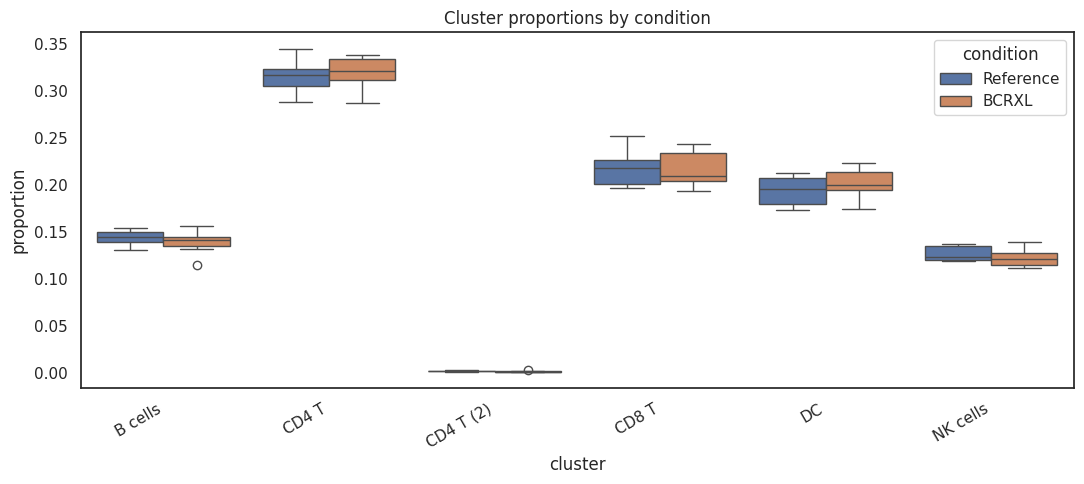

,cluster,ref_mean,bcrxl_mean,p_value
2,CD4 T (2),0.002,0.001,0.2213
4,DC,0.194,0.202,0.3823
5,NK cells,0.127,0.122,0.3823
0,B cells,0.144,0.139,0.5054
1,CD4 T,0.316,0.319,0.6363
3,CD8 T,0.218,0.217,0.9591


In [11]:
counts = df.groupby(["sample_id","cluster_label"]).size().unstack(fill_value=0)
props  = counts.div(counts.sum(axis=1), axis=0).join(meta.set_index("sample_id").condition)
long   = props.melt(id_vars="condition", var_name="cluster", value_name="proportion")

da=[]
for cl,g in long.groupby("cluster"):
    a=g[g.condition=="Reference"].proportion; b=g[g.condition=="BCRXL"].proportion
    da.append(dict(cluster=cl, ref_mean=a.mean().round(3),
                   bcrxl_mean=b.mean().round(3), p_value=round(mannwhitneyu(a,b)[1],4)))
da=pd.DataFrame(da).sort_values("p_value")

plt.figure(figsize=(11,5))
sns.boxplot(data=long, x="cluster", y="proportion", hue="condition")
plt.xticks(rotation=30, ha="right"); plt.title("Cluster proportions by condition")
plt.tight_layout(); plt.show()
da

*No population changes size significantly — correct here: the effect of BCR stimulation is on **signalling**, not on cell numbers. That is what the next step catches.*

## 8 · Differential state — the pharmacodynamic readout

Within each population, does a **signalling** marker change? We compare the per-sample median
of each state marker between conditions. This is the pharmacodynamic question: *did the
pathway switch on?*

In [12]:
ds=[]
for mk in state_markers:
    m=df.groupby(["sample_id","cluster_label"])[mk].median().reset_index()
    m=m.merge(meta[["sample_id","condition"]], on="sample_id")
    for cl,g in m.groupby("cluster_label"):
        a=g[g.condition=="Reference"][mk]; b=g[g.condition=="BCRXL"][mk]
        ds.append(dict(marker=mk, cluster=cl, ref_median=round(a.median(),2),
                       bcrxl_median=round(b.median(),2), p_value=round(mannwhitneyu(a,b)[1],5)))
ds=pd.DataFrame(ds).sort_values("p_value")
ds.head(6)

,marker,cluster,ref_median,bcrxl_median,p_value
0,pS6,B cells,0.10,0.90,0.00016
6,pNFkB,B cells,0.11,0.57,0.00016
1,pS6,CD4 T,0.11,0.09,0.27863
8,pNFkB,CD4 T (2),0.12,0.16,0.27863
3,pS6,CD8 T,0.11,0.10,0.32821
2,pS6,CD4 T (2),0.10,0.14,0.38228


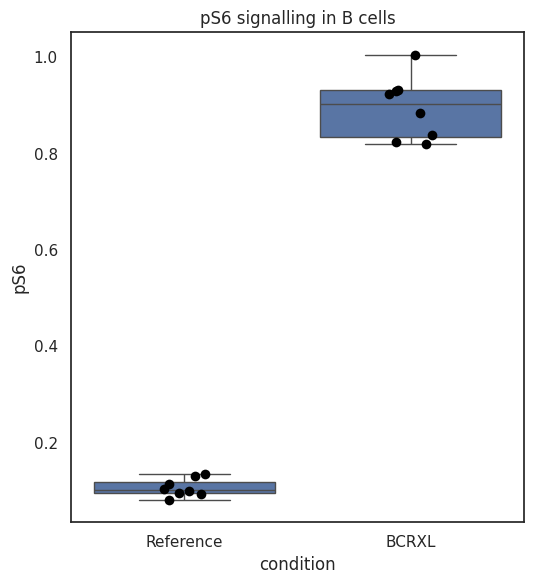

In [13]:
bc = df[df.cluster_label=="B cells"].groupby("sample_id")["pS6"].median().reset_index()
bc = bc.merge(meta[["sample_id","condition"]], on="sample_id")

plt.figure(figsize=(5.5,6))
sns.boxplot(data=bc, x="condition", y="pS6", order=["Reference","BCRXL"])
sns.stripplot(data=bc, x="condition", y="pS6", order=["Reference","BCRXL"],
              color="black", size=7)
plt.title("pS6 signalling in B cells"); plt.tight_layout(); plt.show()

**This is the result.** pS6 jumps in B cells after BCR stimulation (and pNFkB more mildly),
while every other population / marker combination is non-significant. The unsupervised
pipeline located a specific, interpretable pharmacodynamic signal on its own.

## 9 · How good was the clustering?

Because this is a controlled dataset we know each cell's true identity, so we can score the
unsupervised clusters against ground truth with the **Adjusted Rand Index** (1.0 = perfect).
On real data you don't have this luxury — which is exactly why the marker-heatmap and
UMAP-marker checks above matter.

In [14]:
ari = adjusted_rand_score(df["true_label"], df["cluster"])
print(f"Adjusted Rand Index vs ground truth: {ari:.3f}")

Adjusted Rand Index vs ground truth: 0.959


## Conclusion

Starting from raw single-cell intensities and **no manual gating**, the notebook:

- recovered the six immune lineages (ARI ≈ 1.0),
- visualised them with UMAP and validated the labels against marker biology,
- showed there was **no differential abundance**, and
- pinpointed the true pharmacodynamic signal: **pS6 induction in B cells** after stimulation.

### Why this maps to translational / immuno-oncology work
- *Unsupervised clustering of high-dimensional flow data* → steps 4–6.
- *Interpreting and presenting biomarker results* → the annotation, differential tests, and
  narrative here.
- *Analysing single-cell data in Python* → the whole notebook.

### Running it on real data
Swap the simulation in section 1 for real `.fcs` files — read them with
[`fcsparser`](https://github.com/eyurtsev/fcsparser) or
[`FlowKit`](https://github.com/whitews/FlowKit), export a marker table per sample, and feed
it into the identical transform → cluster → differential steps. The canonical public dataset
for this workflow is **Bodenmiller_BCR_XL** (Bioconductor `HDCytoData`, or FlowRepository
`FR-FCM-ZZPH`). The gold-standard R implementation is **CATALYST** + **diffcyt**.